# Visualization with Matplotlib

We'll now take an in-depth look at the Matplotlib package for visualization in Python.
Matplotlib is a multi-platform data visualization library built on NumPy arrays, and designed to work with the broader SciPy stack.
It was conceived by John Hunter in 2002, originally as a patch to IPython for enabling interactive MATLAB-style plotting via gnuplot from the IPython command line.
IPython's creator, Fernando Perez, was at the time scrambling to finish his PhD, and let John know he wouldn’t have time to review the patch for several months.
John took this as a cue to set out on his own, and the Matplotlib package was born, with version 0.1 released in 2003.
It received an early boost when it was adopted as the plotting package of choice of the Space Telescope Science Institute (the folks behind the Hubble Telescope), which financially supported Matplotlib’s development and greatly expanded its capabilities.

One of Matplotlib’s most important features is its ability to play well with many operating systems and graphics backends.
Matplotlib supports dozens of backends and output types, which means you can count on it to work regardless of which operating system you are using or which output format you wish.
This cross-platform, everything-to-everyone approach has been one of the great strengths of Matplotlib.
It has led to a large user base, which in turn has led to an active developer base and Matplotlib’s powerful tools and ubiquity within the scientific Python world.

In recent years, however, the interface and style of Matplotlib have begun to show their age.
Newer tools like ggplot and ggvis in the R language, along with web visualization toolkits based on D3js and HTML5 canvas, often make Matplotlib feel clunky and old-fashioned.
Still, I'm of the opinion that we cannot ignore Matplotlib's strength as a well-tested, cross-platform graphics engine.
Recent Matplotlib versions make it relatively easy to set new global plotting styles (see [Customizing Matplotlib: Configurations and Style Sheets](04.11-Settings-and-Stylesheets.ipynb)), and people have been developing new packages that build on its powerful internals to drive Matplotlib via cleaner, more modern APIs—for example, Seaborn (discussed in [Visualization With Seaborn](04.14-Visualization-With-Seaborn.ipynb)), [ggpy](http://yhat.github.io/ggpy/), [HoloViews](http://holoviews.org/), [Altair](http://altair-viz.github.io/), and even Pandas itself can be used as wrappers around Matplotlib's API.
Even with wrappers like these, it is still often useful to dive into Matplotlib's syntax to adjust the final plot output.
For this reason, I believe that Matplotlib itself will remain a vital piece of the data visualization stack, even if new tools mean the community gradually moves away from using the Matplotlib API directly.

## General Matplotlib Tips

Before we dive into the details of creating visualizations with Matplotlib, there are a few useful things you should know about using the package.

### Importing Matplotlib

Just as we use the ``np`` shorthand for NumPy and the ``pd`` shorthand for Pandas, we will use some standard shorthands for Matplotlib imports:

In [1]:
import matplotlib.pyplot as plt

In [ ]:
# !pip install matplotlib

## Basic Plotting with Matplotlib
Now let's start with the simplest example: a basic line plot.

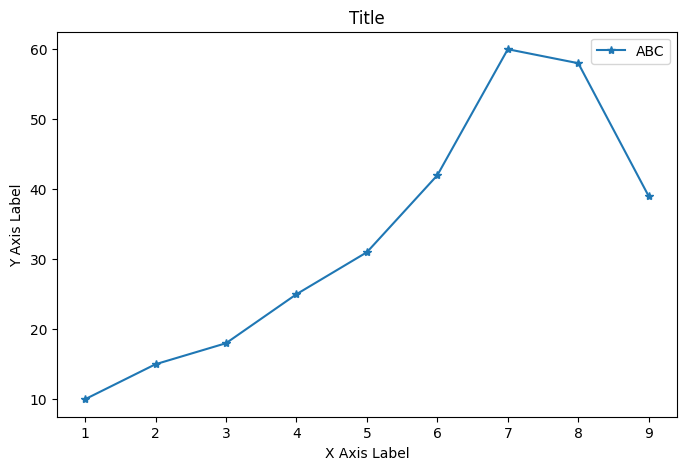

In [5]:
x = [1,2,3,4,5,6,7,8,9]
y = [10, 15, 18, 25, 31, 42, 60, 58, 39]

plt.figure(figsize = (8,5))

plt.title("Title")
plt.xlabel("X Axis Label")
plt.ylabel("Y Axis Label")

plt.plot(x, y,marker = "*", alpha = 1, label = "ABC")

plt.legend()

### ``show()`` or No ``show()``? How to Display Your Plots

A visualization you can't see won't be of much use, but just how you view your Matplotlib plots depends on the context.
The best use of Matplotlib differs depending on how you are using it; roughly, the three applicable contexts are using Matplotlib in a script, in an IPython terminal, or in an IPython notebook.

If you are using Matplotlib from within a script, the function ``plt.show()`` is your friend.
``plt.show()`` starts an event loop, looks for all currently active figure objects, and opens one or more interactive windows that display your figure or figures.

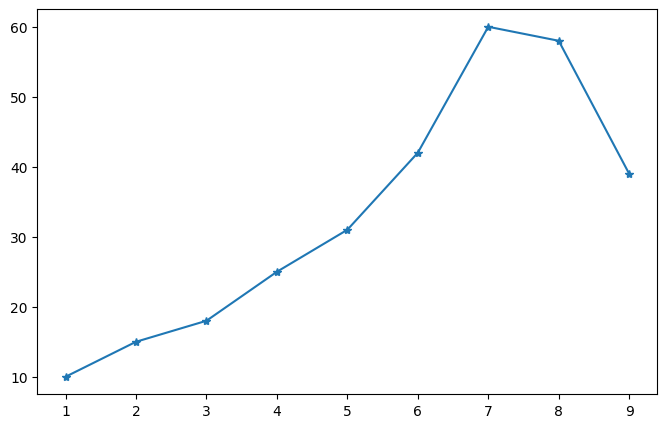

In [6]:
plt.figure(figsize = (8,5))
plt.plot(x, y,marker = "*", alpha = 1, label = "ABC")
plt.show()

The ``plt.show()`` command does a lot under the hood, as it must interact with your system's interactive graphical backend.
The details of this operation can vary greatly from system to system and even installation to installation, but matplotlib does its best to hide all these details from you.

One thing to be aware of: the ``plt.show()`` command should be used *only once* per Python session, and is most often seen at the very end of the script.
Multiple ``show()`` commands can lead to unpredictable backend-dependent behavior, and should mostly be avoided.

### Setting Styles

We will use the ``plt.style`` directive to choose appropriate aesthetic styles for our figures.
Here we will set the ``classic`` style, which ensures that the plots we create use the classic Matplotlib style:

In [7]:
plt.style.use('classic')

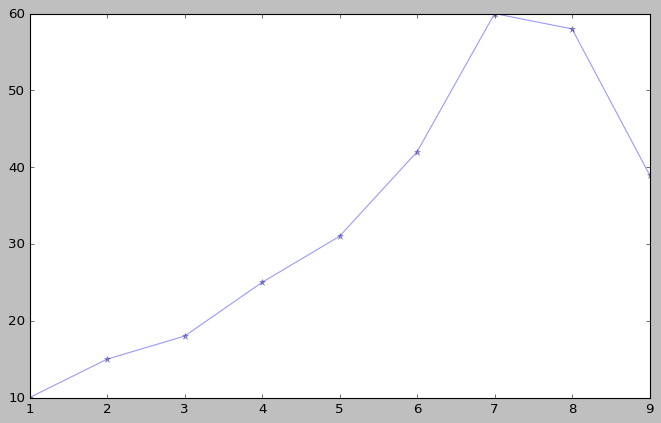

In [10]:
plt.figure(figsize = (10,6))
plt.plot(x, y,marker = "*", alpha = .4, label = "ABC")
plt.show()

## Sub Plots
A subplot is a way to display multiple plots within a single figure in Matplotlib. It allows for efficient visualization of multiple datasets by organizing plots in a grid layout (rows × columns).

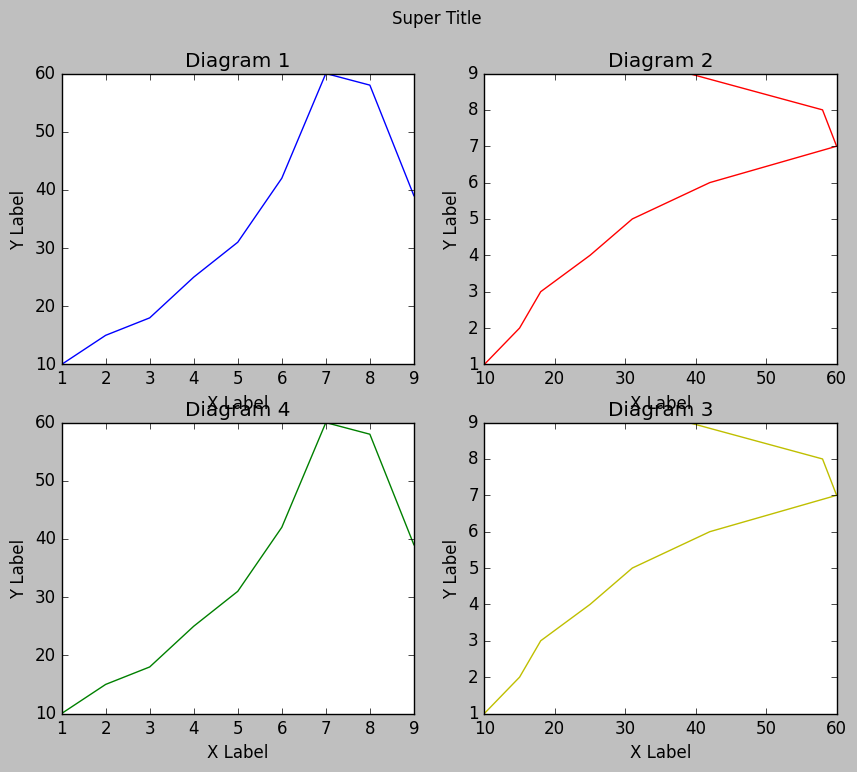

In [21]:
fig, axs = plt.subplots(nrows = 2, ncols = 2,  figsize = (10,8), dpi = 100)

fig.suptitle("Super Title")

axs[0,0].plot(x,y)
axs[0,0].set_title("Diagram 1")
axs[0,0].set_xlabel("X Label")
axs[0,0].set_ylabel("Y Label")

axs[0,1].plot(y,x,color ='r')
axs[0,1].set_title("Diagram 2")
axs[0,1].set_xlabel("X Label")
axs[0,1].set_ylabel("Y Label")

axs[1,1].plot(y,x,color ='y')
axs[1,1].set_title("Diagram 3")
axs[1,1].set_xlabel("X Label")
axs[1,1].set_ylabel("Y Label")

axs[1,0].plot(x,y,color ='g')
axs[1,0].set_title("Diagram 4")
axs[1,0].set_xlabel("X Label")
axs[1,0].set_ylabel("Y Label")

plt.show()

- In the above plot you have a 2×2 grid of plots, each showcasing different trends. While this layout helps compare multiple visualizations side by side, sometimes you might want to present all the data in a single unified plot instead of splitting it across multiple subplots.

To achieve this, you can overlay multiple plots in the same figure, ensuring each dataset is distinguished by unique colors, line styles, and markers. This approach provides a clear, direct comparison without the need to shift focus between subplots. A well-placed legend will help differentiate the datasets, while carefully adjusting transparency (alpha), line widths, and markers ensures readability.

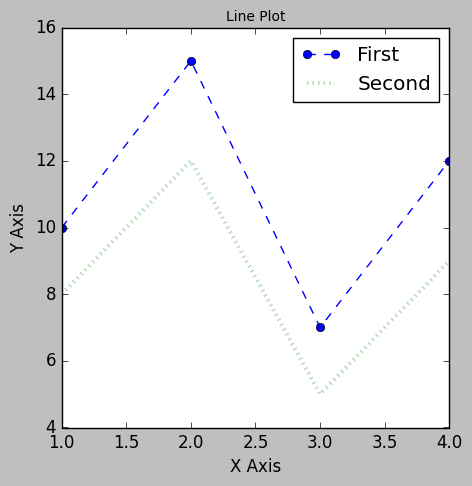

In [22]:
# Sample data
x1, y1 = [1, 2, 3, 4], [10, 15, 7, 12]
x2, y2 = [1, 2, 3, 4], [8, 12, 5, 9]

plt.figure(figsize=(5, 5), dpi=100)
plt.title("Line Plot", fontsize=10)

plt.plot(x1, y1, 'o--', label="First")
plt.plot(x2, y2, 'g:', linewidth=3, alpha=0.3, label="Second")

plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.legend()
plt.savefig("plot.jpeg")
plt.show()

The ``plt`` interface is what we will use most often, as we shall see throughout this chapter.

### Saving Figures to File

One nice feature of Matplotlib is the ability to save figures in a wide variety of formats.
Saving a figure can be done using the ``savefig()`` command.
For example, to save the previous figure as a PNG file, you can run this:

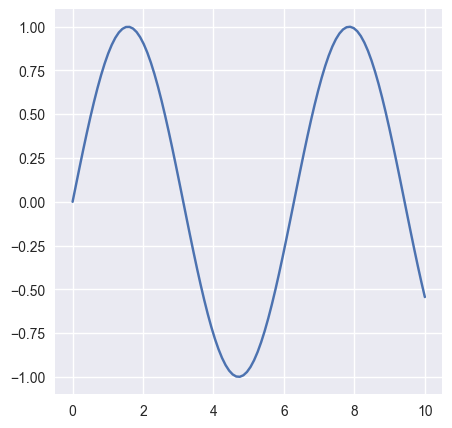

In [ ]:
plt.figure(figsize = (5,5), dpi = 100)
x = np.linspace(0, 10, 100)
plt.plot(x, np.sin(x))
plt.savefig('my_figure1.pdf') #  eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff

We now have a file called ``my_figure.png`` in the current working directory:

In ``savefig()``, the file format is inferred from the extension of the given filename.
Depending on what backends you have installed, many different file formats are available.
The list of supported file types can be found for your system by using the following method of the figure canvas object:

In [ ]:
fig.canvas.get_supported_filetypes()

{'eps': 'Encapsulated Postscript',
 'jpeg': 'Joint Photographic Experts Group',
 'jpg': 'Joint Photographic Experts Group',
 'pdf': 'Portable Document Format',
 'pgf': 'PGF code for LaTeX',
 'png': 'Portable Network Graphics',
 'ps': 'Postscript',
 'raw': 'Raw RGBA bitmap',
 'rgba': 'Raw RGBA bitmap',
 'svg': 'Scalable Vector Graphics',
 'svgz': 'Scalable Vector Graphics',
 'tif': 'Tagged Image File Format',
 'tiff': 'Tagged Image File Format'}

Note that when saving your figure, it's not necessary to use ``plt.show()`` or related commands discussed earlier.

# Introduction to Statistics

Statistics is a set of scientific principles and techniques that are useful in reaching conclusions about populations and processes when the available information is both limited and variable; that is, <h3>statistics is the science of learning from data.</h3>

### Terminology:

A **variable** is a characteristic that changes or varies over time and/or for different individuals or objects under consideration. For example, body temperature is a variable that changes over time within a single individual; it also varies from person to person.

An **experimental unit** is the individual or object on which a variable is measured. A single measurement or data value results when a variable is actually measured on an experimental unit.

A **population** is the set of all measurements of interest to the investigator. A **sample** is a subset of measurements selected from the population of interest. For the body-temperature experiment, the sample is the set of body-temperature measurements for the 148 healthy people chosen by the experimenter. We hope that the sample is representative of a much larger body of measurements—the population—the body temperatures of all healthy people in the world!

**Univariate data** result when a single variable is measured on a single experimental unit. If you measure the body temperatures of 148 people, the resulting data are univariate.
**Bivariate data** result when two variables are measured on a single experimental unit. **Multivariate data** result when more than two variables are measured.

### Types of variables:

**Qualitative variables** produce data that can be categorized according to similarities or differences in kind; hence, they are often called categorical data. e.g.,

Political affiliation: Republican, Democrat, Independent

Taste ranking: excellent, good, fair, poor


**Quantitative variables**  measure a numerical quantity or amount on each experimental unit. e.g.,

x =Prime interest rate

x =Number of passengers on a flight from Los Angeles to NY

There are two types of quantitative variables: discrete and continuous.

1. A **discrete variable** can assume only a finite or countable number of values. The name discrete relates to the discrete gaps between the possible values that the variable can assume. Variables such as number of family members, number of new car sales, and number of defective tires returned for replacement are all examples of discrete variables.

2. A **continuous variable** can assume the infinitely many values corresponding to the points on a line interval.Variables such as height, weight, time, distance, and volume are continuous because they can assume values at any point along a line interval. For any two values you pick, a third value can always be found between them!

## Statistical Visualization with Matplotlib
When working with data, visualizing statistical aspects can be incredibly helpful to understand the underlying patterns. Matplotlib, in combination with other libraries like NumPy and Pandas, provides tools to perform statistical visualizations, including:

- Univariate analysis: Analyzing the distribution of a single variable.
- Bivariate analysis: Analyzing the relationship between two variables.

Let’s break it down and explore how we can use Matplotlib for these analyses.

## Univariate Analysis
Univariate analysis focuses on a single variable, and the goal is to explore its distribution, central tendency, and spread. Key plots for univariate analysis include histograms, boxplots, and density plots.

## Pie chart
A circular graphic used to display the percentage of the total number of measurements falling into each of the categories of the variable by partitioning a circle nto slices to illustrate numerical proportion. The point of a pie chart is to show the relationship of parts out of a whole.

In [2]:
# Data Expectation - array of numbers - each number representing the contribution / frequency of a particular calss
import pandas as pd
titanic = pd.read_csv("titanic3.csv")
titanic.head(2)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"


In [3]:
titanic['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

In [4]:
titanic['sex'].value_counts().index.str.upper()

Index(['MALE', 'FEMALE'], dtype='object', name='sex')

In [5]:
titanic['sex'].value_counts().values

array([843, 466], dtype=int64)

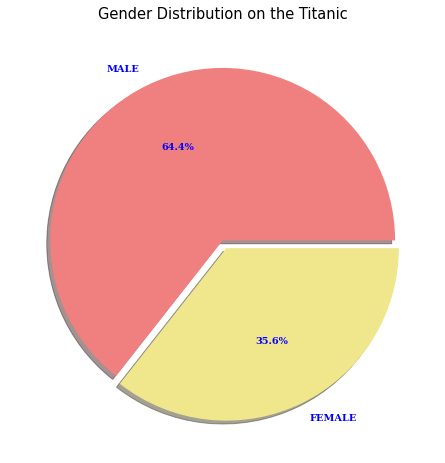

In [6]:
plt.figure(figsize = (8,8), dpi = 70)
plt.title("Gender Distribution on the Titanic", fontsize = 15)

plt.pie(titanic['sex'].value_counts().values, labels = titanic['sex'].value_counts().index.str.upper(),
        colors = ["lightcoral", "khaki"],
        autopct =  '%.1f%%', shadow = True,
        textprops = {"family" : "serif","color" : "blue", "weight":"bold"},
        explode = (0, 0.05))
plt.show()

In [ ]:
titanic.drop(1309, inplace = True)

In [7]:
titanic['survived'] = titanic['survived'].replace({0:"Dead", 1:"Survived"})

In [8]:
titanic['count'] = 1
table = titanic.pivot_table(index = 'sex', columns = 'survived' , values = 'count', aggfunc = 'sum')

In [9]:
table

survived,Dead,Survived
sex,,
female,127,339
male,682,161


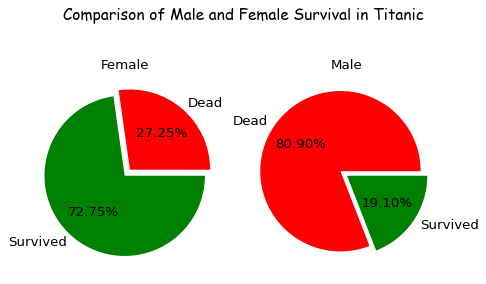

In [10]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(6, 4), dpi = 80, constrained_layout=True)

plt.suptitle("Comparison of Male and Female Survival in Titanic", fontsize=14, family = 'cursive')

axs[0].pie(table.loc['female'].values, labels = table.loc['female'].index,
           colors = ['red','green'], autopct = "%1.2f%%", explode = (0.1, 0),
           textprops={'size': 'larger'})
axs[0].set_title("Female")


axs[1].pie(table.loc['male'].values, labels = table.loc['male'].index,
           colors = ['red','green'], autopct = "%1.2f%%", explode = (0.1, 0),
           textprops={'size': 'larger'})
axs[1].set_title("Male")

plt.show()

### Exercise
Create a pie chart to visualize the distribution of passengers based on whether they survived or not.

# Bar Chart
A Bar Plot (or Bar Chart) is one of the most commonly used visualizations in statistics and data analysis. It is used to compare the frequency, count, or any other measure (like mean, sum, etc.) across different categories. Each category is represented by a bar, where the height of the bar corresponds to the value of the variable it represents.

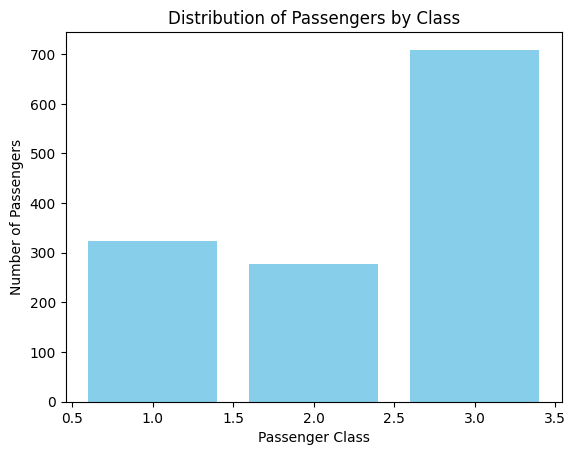

In [ ]:
# Count the number of passengers in each Pclass
pclass_counts = titanic['pclass'].value_counts().sort_index()

# Create a bar plot
plt.bar(pclass_counts.index, pclass_counts.values, color='skyblue')

# Adding title and labels
plt.title('Distribution of Passengers by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

# Show the plot
plt.show()

- You can make the bar plot more visually appealing by adding some annotations, improving the labels, and enhancing the overall presentation.

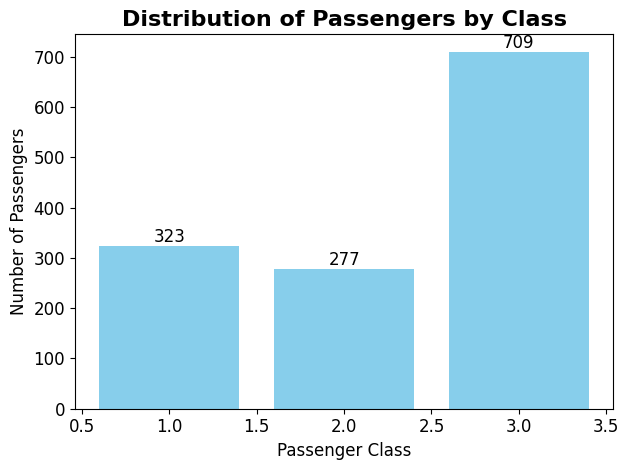

In [ ]:
# Count the number of passengers in each Pclass
pclass_counts = titanic['pclass'].value_counts().sort_index()

# Create a bar plot
plt.bar(pclass_counts.index, pclass_counts.values, color='skyblue')

# Add annotations on top of the bars
for i, count in enumerate(pclass_counts.values):
    plt.text(pclass_counts.index[i], count + 0.1, str(count), ha='center', va='bottom', fontsize=12, color='black')

# Adding title and labels with improved styling
plt.title('Distribution of Passengers by Class', fontsize=16, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Customize the x-axis labels with rotation for clarity
plt.xticks(rotation=0, fontsize=12)

# Customize y-axis ticks to make them more readable
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

- You can make this plot as horizontal as well just change the bar to barh

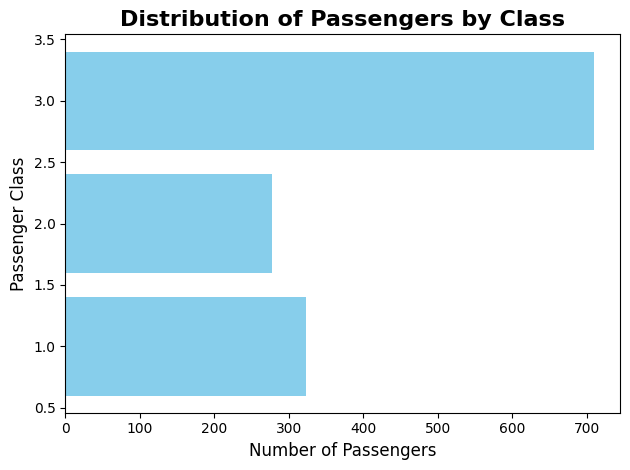

In [ ]:
# Count the number of passengers in each Pclass
pclass_counts = titanic['pclass'].value_counts().sort_index()

# Create a horizontal bar plot
plt.barh(pclass_counts.index, pclass_counts.values, color='skyblue')

# Adding title and labels with improved styling
plt.title('Distribution of Passengers by Class', fontsize=16, fontweight='bold')
plt.xlabel('Number of Passengers', fontsize=12)
plt.ylabel('Passenger Class', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

### Exercise
Create a horizontal bar plot that shows the distribution of passengers across different passenger embarked.

## Histogram
Pie charts and bar charts are used to display frequency data from qualitative variables; histograms are appropriate for displaying frequency data for quantitative variables.

A histogram represents the frequencies of values of a variable bucketed into ranges. Histogram is similar to bar chat but the difference is it groups the values into continuous ranges. Each bar in histogram represents the height of the number of values present in that range.

A histogram consists of parallel vertical bars that graphically shows the frequency distribution of a quantitative variable. The area of each bar is equal to the frequency of items found in each class.

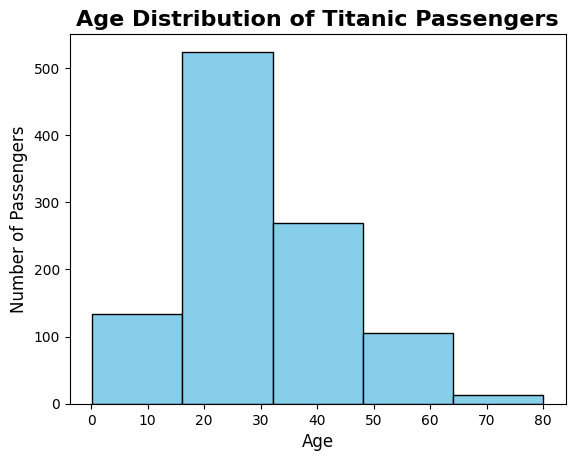

In [ ]:
# Create the histogram
plt.hist(titanic['age'], bins=5, color='skyblue', edgecolor='black')

# Adding title and labels
plt.title('Age Distribution of Titanic Passengers', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Show the plot
plt.show()

## Box Plot
A box plot (also known as a box-and-whisker plot) is a graphical representation of the distribution of a dataset, highlighting the median, quartiles, and outliers. It's an excellent way to visualize the spread of data and to compare distributions between different groups.

In [3]:
listings=pd.read_csv('listings.csv')

In [ ]:
listings.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,49091,COZICOMFORT LONG TERM STAY ROOM 2,266763,Francesca,North Region,Woodlands,1.44255,103.79580,Private room,83,180,1,2013-10-21,0.01,2,365
1,50646,Pleasant Room along Bukit Timah,227796,Sujatha,Central Region,Bukit Timah,1.33235,103.78521,Private room,81,90,18,2014-12-26,0.28,1,365
2,56334,COZICOMFORT,266763,Francesca,North Region,Woodlands,1.44246,103.79667,Private room,69,6,20,2015-10-01,0.20,2,365
3,71609,Ensuite Room (Room 1 & 2) near EXPO,367042,Belinda,East Region,Tampines,1.34541,103.95712,Private room,206,1,14,2019-08-11,0.15,9,353
4,71896,B&B Room 1 near Airport & EXPO,367042,Belinda,East Region,Tampines,1.34567,103.95963,Private room,94,1,22,2019-07-28,0.22,9,355


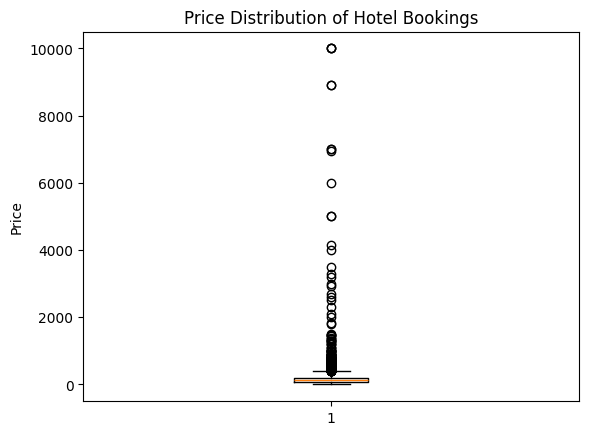

In [ ]:
# Create a box plot
plt.boxplot(listings['price'])

# Adding title and labels
plt.title('Price Distribution of Hotel Bookings')
plt.ylabel('Price')

# Show the plot
plt.show()

# Bivariate analysis
Bivariate analysis is a statistical method used to examine the relationship between two variables. It helps to understand how one variable is related to or influenced by another. Bivariate analysis can be used to identify patterns, trends, or correlations between two variables, and it's commonly used in both descriptive and inferential statistics.

## Stacked Bar Plot
A Stacked Bar Plot (also known as a grouped bar chart) is a type of chart that displays the values of different categories of data side by side for comparison. It is particularly useful when you want to compare multiple groups or categories across different sub-groups.

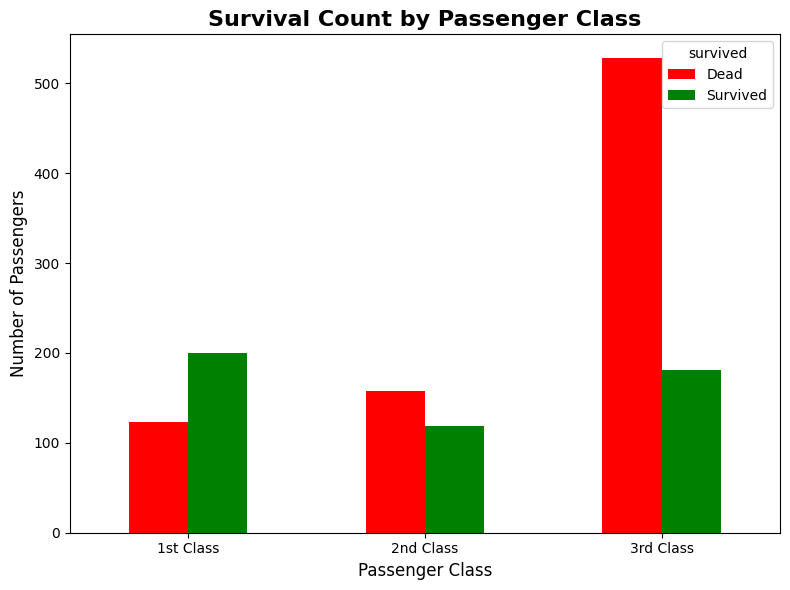

In [11]:
# Count the number of survivors and non-survivors by Pclass
survival_counts = titanic.groupby(['pclass', 'survived']).size().unstack(fill_value=0)

# Create a grouped bar chart
survival_counts.plot(kind='bar', figsize=(8, 6), color=['red', 'green'])

# Adding title and labels
plt.title('Survival Count by Passenger Class', fontsize=16, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Customize the x-axis tick labels
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'], rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

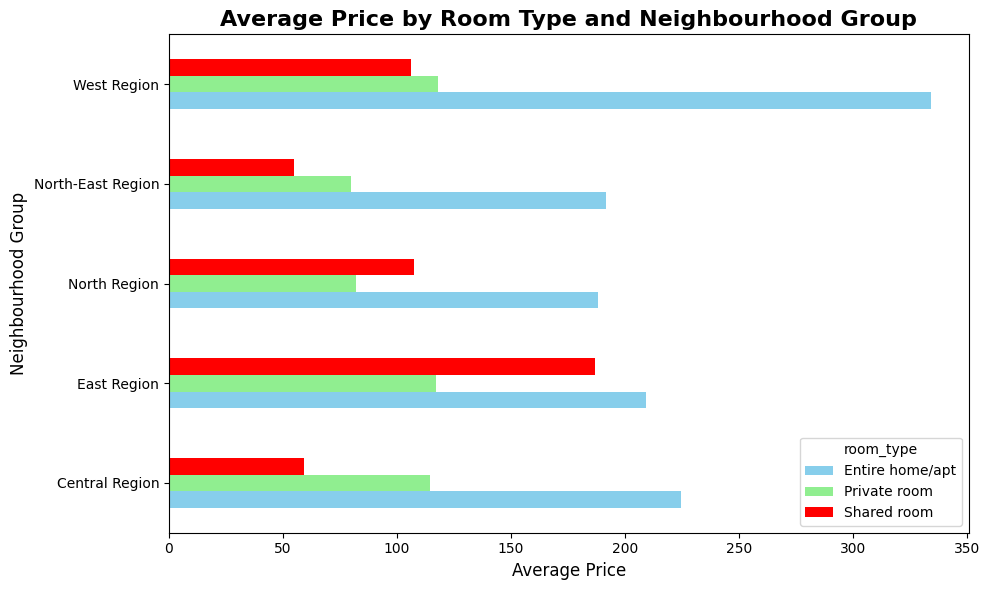

In [15]:
# Group by neighbourhood_group and room_type, then calculate the mean price
grouped_data = listings.groupby(['neighbourhood_group', 'room_type'])['price'].mean().unstack()

# Create a horizontal grouped bar chart
grouped_data.plot(kind='barh', figsize=(10, 6), color=['skyblue', 'lightgreen','red'])

# Adding title and labels
plt.title('Average Price by Room Type and Neighbourhood Group', fontsize=16, fontweight='bold')
plt.xlabel('Average Price', fontsize=12)
plt.ylabel('Neighbourhood Group', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

### Exercise
Create a stacked bar plot to visualize the average room prices for different room types within each neighbourhood group in the listings dataset.

## Violin Plot
A violin plot is a combination of a box plot and a kernel density plot, and it is used to visualize the distribution of a continuous variable across different categorical variables. It provides a deeper insight into the data by not only displaying summary statistics (like the median and quartiles) but also showing the density of the data at different values, making it particularly useful for understanding the shape and spread of the data.

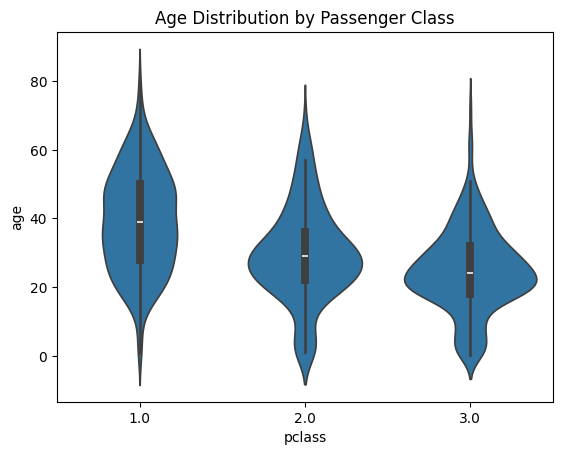

In [ ]:
import seaborn as sns

# Create a violin plot of age by passenger class
sns.violinplot(x="pclass", y="age", data=titanic)
# Adding title
plt.title('Age Distribution by Passenger Class')
# Show the plot
plt.show()

- You we use seaborn here, while Matplotlib is the foundational plotting library in Python and provides a high level of customization, Seaborn is built on top of Matplotlib to make creating statistical plots easier and more intuitive.

## Scatter Plot
A scatter plot is a type of data visualization that uses dots to represent individual data points in a two-dimensional space. The two axes represent two different variables, and each dot's position corresponds to the values of those variables for a particular observation. Scatter plots are particularly useful for visualizing the relationship between two continuous variables.

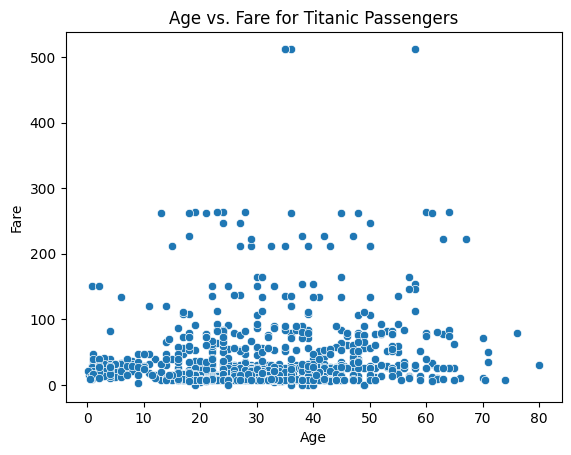

In [22]:
# Create a scatter plot of age vs. fare
sns.scatterplot(x="age", y="fare", data=titanic)

# Adding title and labels
plt.title('Age vs. Fare for Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Fare')

# Show the plot
plt.show()

- You can use the hue parameter to color points based on a categorical variable, such as survival status or passenger class.

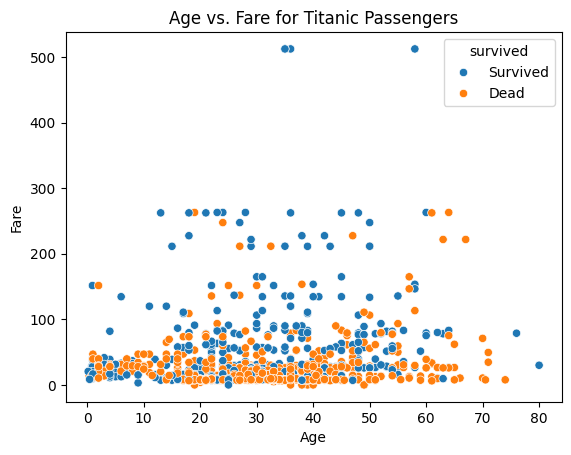

In [ ]:
# Create a scatter plot of age vs. fare
sns.scatterplot(x="age", y="fare", hue="survived", data=titanic)

# Adding title and labels
plt.title('Age vs. Fare for Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Fare')

# Show the plot
plt.show()

### Exercise
Create a Scatter plot between `price` and `minimum_nights` from listings dataset

# Double Axis
A double-axis plot (also known as a dual-axis plot) is a type of graph that displays two different data sets with different scales on the same chart using two vertical axes—one on the left and one on the right. It is useful for comparing trends between two related variables that have different units or magnitudes.

In [ ]:
sales=pd.read_csv('100 Sales Records.csv')

In [ ]:
sales.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,5/2/2014,341417157,5/8/2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,7/5/2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2/1/2013,115456712,2/6/2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50


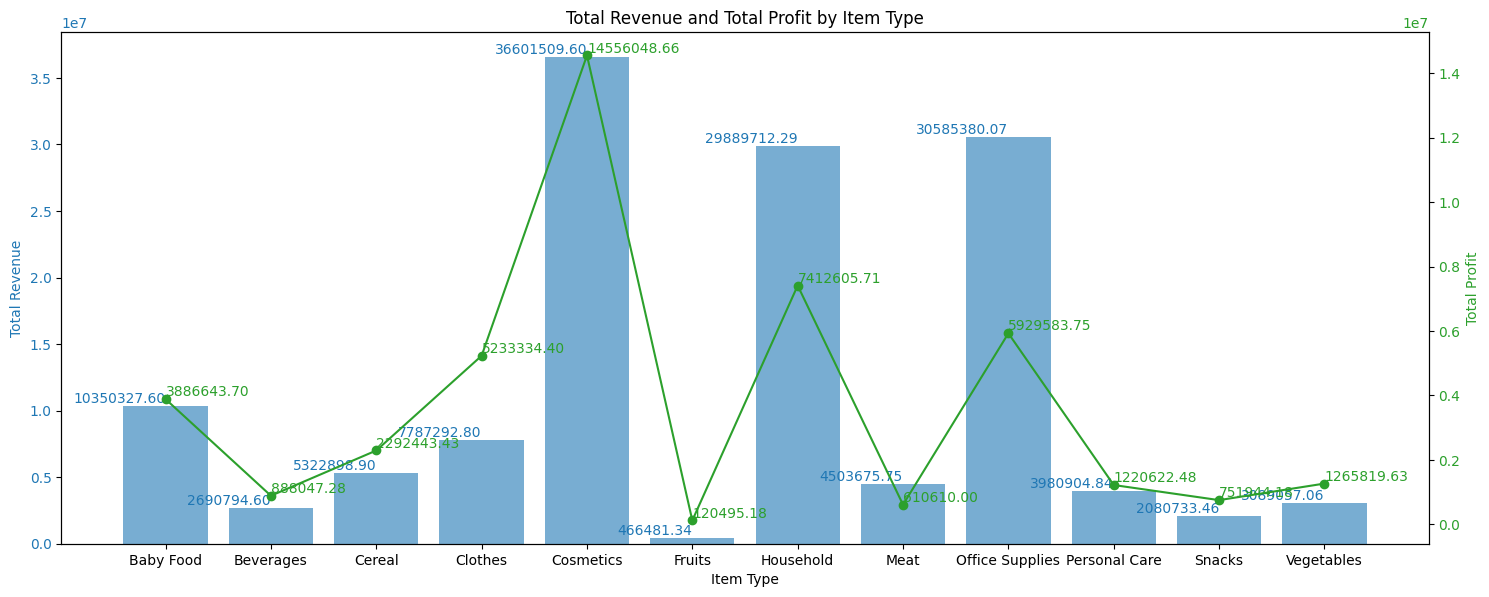

In [17]:
# Create a figure and axis object
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot Total Revenue on the first axis grouped by Item Type
ax1.set_xlabel('Item Type')
ax1.set_ylabel('Total Revenue', color='tab:blue')
df_grouped_revenue = sales.groupby('Item Type')['Total Revenue'].sum()
bars = ax1.bar(df_grouped_revenue.index, df_grouped_revenue, color='tab:blue', alpha=0.6, label='Total Revenue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Annotate the bars with Total Revenue values
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}', ha='right', va='bottom', color='tab:blue')

# Create a second axis object for the Total Profit grouped by Item Type
ax2 = ax1.twinx()
ax2.set_ylabel('Total Profit', color='tab:green')
df_grouped_profit = sales.groupby('Item Type')['Total Profit'].sum()
line, = ax2.plot(df_grouped_profit.index, df_grouped_profit, color='tab:green', marker='o', label='Total Profit')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Annotate the points on the line with Total Profit values
for i, txt in enumerate(df_grouped_profit):
    ax2.text(df_grouped_profit.index[i], txt, f'{txt:.2f}', ha='left', va='bottom', color='tab:green')

# Title and display the plot
fig.tight_layout()
plt.title('Total Revenue and Total Profit by Item Type')
plt.show()

# Measures of Shape

The histogram can give you a general idea of the shape, but two numerical measures of shape give a more precise evaluation: skewness tells you the amount and direction of skew (departure from horizontal symmetry), and kurtosis tells you how tall and sharp the central peak is, relative to a standard bell curve.

Why do we care? One application is testing for normality: many statistics inferences require that a distribution be normal or nearly normal. A normal distribution has skewness and excess kurtosis of 0, so if your distribution is close to those values then it is probably close to normal.

## **1. Skewnewss:**

Skewness is a measure of symmetry, or more precisely, the lack of symmetry. A distribution, or data set, is symmetric if it looks the same to the left and right of the center point.

The first thing you usually notice about a distribution’s shape is whether it has one mode (peak) or more than one. If it’s unimodal (has just one peak), like most data sets, the next thing you notice is whether it’s symmetric or skewed to one side. If the bulk of the data is at the left and the right tail is longer, we say that the distribution is skewed right or positively skewed; if the peak is toward the right and the left tail is longer, we say that the distribution is skewed left or negatively skewed.

The skewness for a normal distribution is zero, and any symmetric data should have a skewness near zero. Negative values for the skewness indicate data that are skewed left and positive values for the skewness indicate data that are skewed right. By skewed left, we mean that the left tail is long relative to the right tail. Similarly, skewed right means that the right tail is long relative to the left tail. If the data are multi-modal, then this may affect the sign of the skewness.

The formula for skewness is:

$$
\text{Skewness} = \frac{\frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^3}{s^3}
$$

Where:
- $\bar{x}$ is the mean of the data,
- $s$ is the standard deviation (calculated with $N$ in the denominator),
- $N$ is the number of data points.

In [20]:
irisdata=pd.read_csv('Iris.csv')

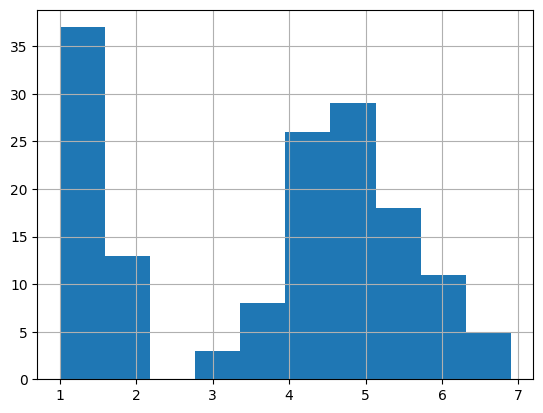

In [24]:
irisdata['Petal length'].hist()
plt.show()

In [21]:
from scipy import stats
x = irisdata['Petal length']
stats.skew(x)

-0.2721276664567214

## Exercise
Plot histogram on 'Petal length' column from iris data then calculate skewness on that column

## **2. Kurtosis:**

Kurtosis is a measure of whether the data are heavy-tailed or light-tailed relative to a normal distribution. That is, data sets with high kurtosis tend to have heavy tails, or outliers. Data sets with low kurtosis tend to have light tails, or lack of outliers. A uniform distribution would be the extreme case.

The kurtosis for a standard normal distribution is three. For this reason, some sources use the following definition of kurtosis (often referred to as "excess kurtosis"):
The formula for kurtosis is:

$$
\text{Kurtosis} = \frac{\frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^4}{s^4} - 3
$$

Where:
- $ \bar{x} $ is the mean of the data,
- $ s $ is the standard deviation (calculated with $ N $ in the denominator),
- $ N $ is the number of data points.

This definition is used so that the standard normal distribution has a kurtosis of zero. In addition, with the second definition positive kurtosis indicates a "heavy-tailed" distribution and negative kurtosis indicates a "light tailed" distribution.

When the distribution of the data is similar to the normal distribution or the kurtosis of the distribution is 3, it is called as **Mesokurtic distribution**. Any distribution which has kurtosis more than Normal distribution (K>3), it is called as **leptokurtic (thin) distribution**. This type distribution has positive kurtosis. Distribution which has kurtosis less than Normal distribution (K < 3), it is called as **platykurtic(flat) distribution**. This type distribution has negative kurtosis.

In [ ]:
irisdata['Petal length'].kurt()

-1.4021034155217518

# Multivariate Analysis:
Multivariate analysis refers to statistical methods used to analyze and understand the relationships between more than two variables. In this case, the scatterplot matrix is a visual technique to understand the pairwise relationships between the features (variables) in the dataset.

For example, in the Iris dataset, this scatterplot matrix would show how the measurements (like sepal length, sepal width, petal length, and petal width) correlate with each other, and how these relationships differ between different species (the "Class" column).

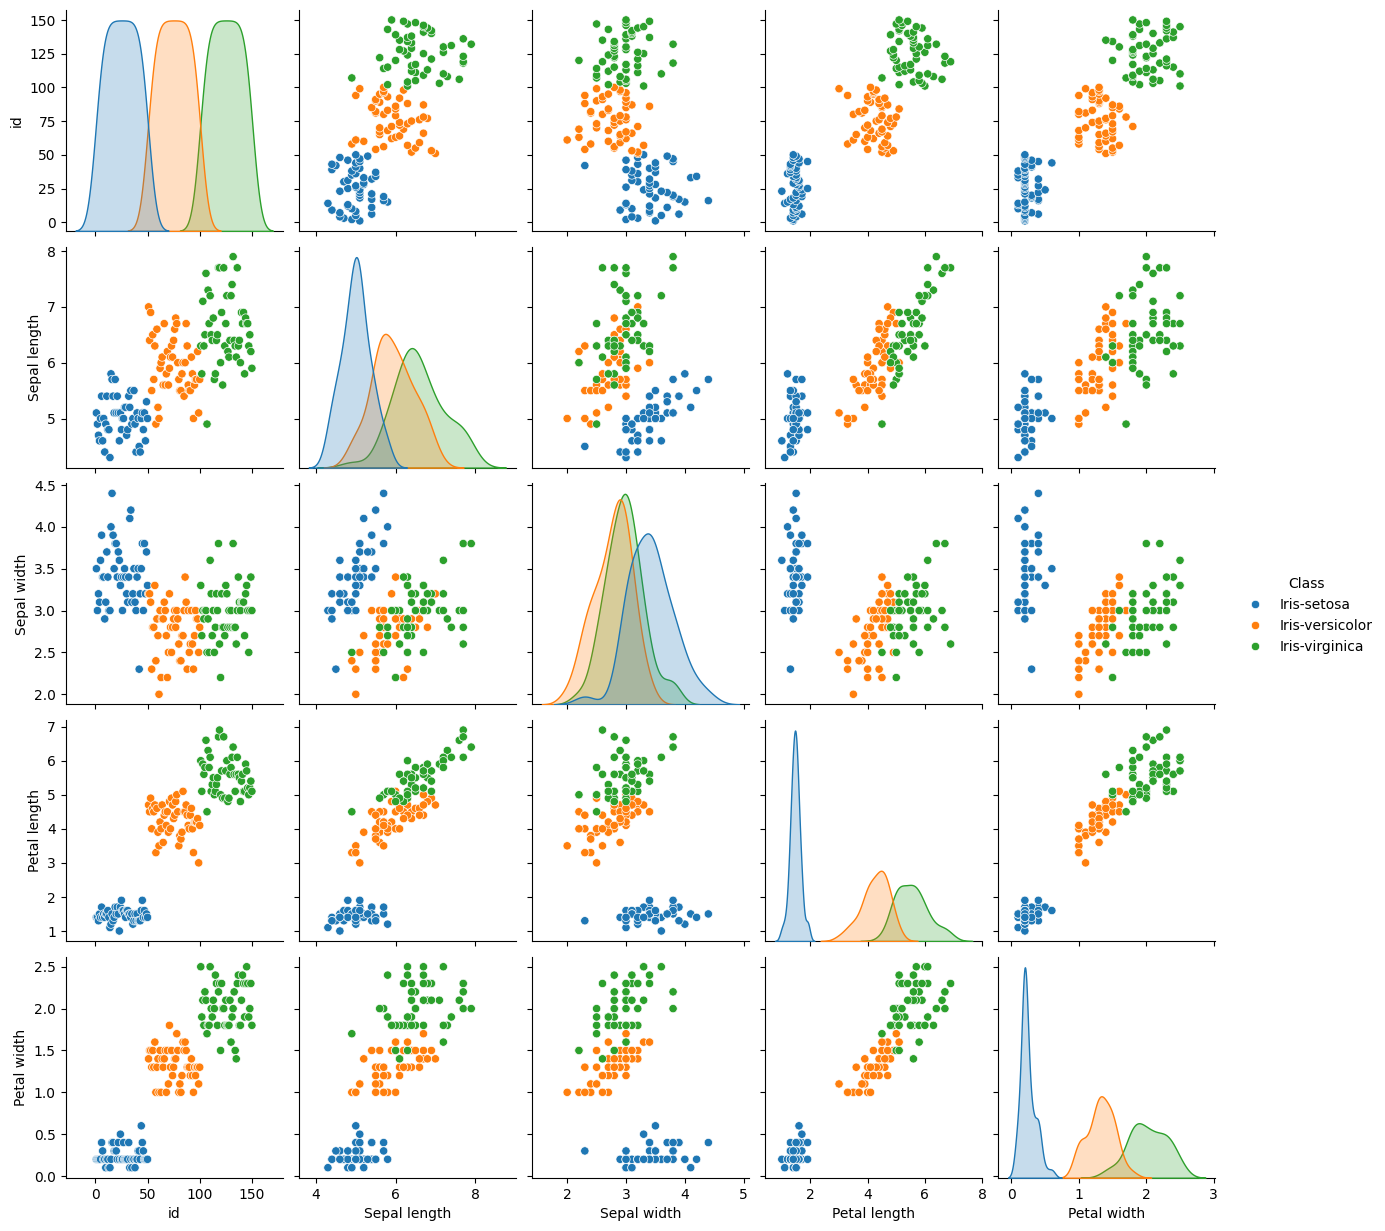

In [ ]:
import seaborn as sns
# create scatterplot matrix
fig = sns.pairplot(data=irisdata,
                   hue='Class') # defines the colors based on the category in the hue column

# Statistical Feature Selection

## Correlation Matrix (Continuous Vs Continuous)
The correlation matrix is a square matrix that contains the Pearson product-moment
correlation coefficients (often abbreviated as Pearson's r), which measure the linear
dependence between pairs of features. The correlation coefficients are bounded
to the range -1 and 1. Two features have a perfect positive correlation if $r=1$, no
correlation if $r=0$ and a perfect negative correlation if $r=-1$ respectively. Pearson's correlation coefficient can simply be calculated as
the covariance between two features $x$ and $y$ (numerator) divided by the product
of their standard deviations (denominator):  

$$r_{xy}=\frac{\sum{(X_{i}-\bar{X})(y_{i}-\bar{y})}}{\sqrt{\sum(X_{i}-\bar{X})^2 \sum(y_{i}-\bar{y})^2}}$$


* This value can be calculated only between two numeric columns
* Correlation between [-1,0) means inversely proportional, the scatter plot will show a downward trend
* Correlation between (0,1] means directly proportional, the scatter plot will show a upward trend
* Correlation near {0} means No relationship, the scatter plot will show no clear trend.
* If Correlation value between two variables is > 0.5 in magnitude, it indicates good relationship the sign does not matter
* We observe the correlations between Target variable and all other predictor variables(s) to check which columns/features/predictors are actually related to the target variable in question

In [25]:
# Calculate the correlation matrix, excluding the 'Species' column
correlation_matrix = irisdata.drop(columns=['Class']).corr()

correlation_matrix

,Sepal length,Sepal width,Petal length,Petal Width
Sepal length,1.000000,-0.117570,0.871754,0.817941
Sepal width,-0.117570,1.000000,-0.428440,-0.366126
Petal length,0.871754,-0.428440,1.000000,0.962865
Petal Width,0.817941,-0.366126,0.962865,1.000000


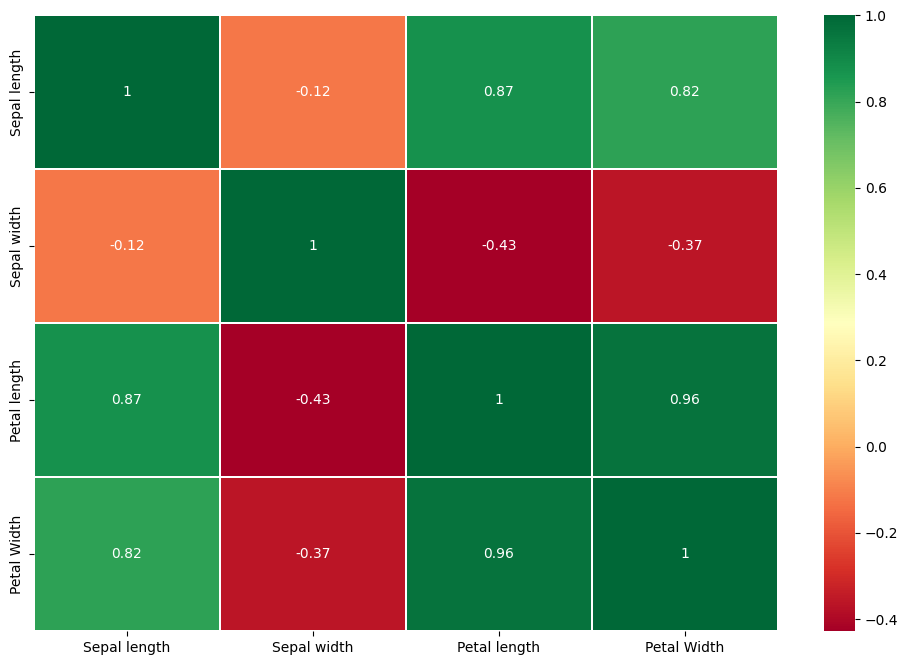

In [28]:
import seaborn as sns
corr = irisdata.corr(numeric_only = True)
# plot the heatmap
plt.figure(figsize = (12,8))
sns.heatmap(corr,
         annot = True, cmap = "RdYlGn", linewidth = 0.3)
plt.show()

## ANOVA test (Continuous Vs Categorical)
Analysis of variance(ANOVA) is performed to check if there is any relationship between the given continuous and categorical variable
* Assumption(H0): There is NO relation between the given variables (i.e. The average(mean) values of the numeric Target variable is same for all the groups in the categorical predictor variable)
* ANOVA Test result: Probability of H0 being true

In [32]:
# Defining a function to find the statistical relationship with all the categorical variables
def FunctionAnova(inpData, TargetVariable, PredictorList):
    from scipy.stats import f_oneway

    # Creating an empty list of final selected predictors
    SelectedPredictors=[]

    print('##### ANOVA Results ##### \n')
    for predictor in PredictorList:
        CategoryGroupLists=inpData.groupby(TargetVariable)[predictor].apply(list)
        AnovaResults = f_oneway(*CategoryGroupLists)

        # If the ANOVA P-Value is <0.05, that means we reject H0
        if (AnovaResults[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', AnovaResults[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', AnovaResults[1])

    return (SelectedPredictors)

In [33]:
continuous_columns=['Sepal length', 'Sepal width', 'Petal length', 'Petal Width']

In [ ]:
# Calling the function to check which continuousl variables are correlated with target(categorical)
FunctionAnova(inpData=irisdata, TargetVariable="Class", PredictorList=continuous_columns)

##### ANOVA Results ##### 

Sepal length is correlated with Class | P-Value: 1.669669190769383e-31
Sepal width is correlated with Class | P-Value: 4.49201713330911e-17
Petal length is correlated with Class | P-Value: 2.856776610961539e-91
Petal Width is correlated with Class | P-Value: 4.1694458394430593e-85


['Sepal length', 'Sepal width', 'Petal length', 'Petal Width']

## Chi-Square Test (Categorical Vs Categorical)
Chi-Square test is conducted to check the correlation between two categorical variables

* Assumption(H0): The two columns are NOT related to each other
* Result of Chi-Sq Test: The Probability of H0 being True

In [44]:
# Writing a function to find the correlation of all categorical variables with the Target variable
def FunctionChisq(inpData, TargetVariable, CategoricalVariablesList):
    from scipy.stats import chi2_contingency

    # Creating an empty list of final selected predictors
    SelectedPredictors=[]

    print('##### chi-square Results ##### \n')
    for predictor in CategoricalVariablesList:
        CrossTabResult=pd.crosstab(index=inpData[TargetVariable], columns=inpData[predictor])
        ChiSqResult = chi2_contingency(CrossTabResult)

        # If the ChiSq P-Value is <0.05, that means we reject H0, -> p low, null go
        if ( ChiSqResult[1] < 0.05 ):
            SelectedPredictors.append(predictor)
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])

    return(SelectedPredictors)

In [46]:
categorical_col=['pclass','sex','sibsp','parch','embarked']

In [47]:
FunctionChisq(inpData=titanic,TargetVariable="survived",CategoricalVariablesList= categorical_col)

##### chi-square Results ##### 

pclass is correlated with survived | P-Value: 1.7208259588256052e-28
sex is correlated with survived | P-Value: 4.589924936952945e-81
sibsp is correlated with survived | P-Value: 9.289432216905344e-08
parch is correlated with survived | P-Value: 2.484746023509338e-09
embarked is correlated with survived | P-Value: 2.471880987482563e-10


['pclass', 'sex', 'sibsp', 'parch', 'embarked']